# Olist Growth and Operations Analytics

## Portfolio Visual Analysis

This notebook converts the PostgreSQL analytical outputs from the Olist project into portfolio-ready visualisations.

The analysis covers:

- Monthly sales performance
- Customer growth
- Cohort retention
- RFM customer segmentation
- Product-category performance
- Delivery and customer-review outcomes
- Regional delivery performance
- Seller operational risk

The visualisations are generated from validated CSV reports in the `reports/` directory and saved as PNG files in the `visuals/` directory.

### Important metric definitions

- **Completed order:** An order with `order_status = 'delivered'`.
- **Valid delivery order:** A completed order with complete and logically consistent delivery timestamps.
- **Low review:** An order with a review score of 1 or 2.
- **High-value seller:** A seller ranked within the top 100 by item revenue.
- **Eligible risk-analysis seller:** A seller with at least 20 valid deliveries and 20 reviewed orders.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Make the notebook work from either the repository root
# or the notebooks directory.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORT_DIR = PROJECT_ROOT / "reports"
VISUAL_DIR = PROJECT_ROOT / "visuals"

VISUAL_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 15,
    "font.size": 10
})

print("Project root:", PROJECT_ROOT)
print("Report directory:", REPORT_DIR)
print("Visual directory:", VISUAL_DIR)

Project root: /Users/liyang/Documents/olist-growth-operations-analytics
Report directory: /Users/liyang/Documents/olist-growth-operations-analytics/reports
Visual directory: /Users/liyang/Documents/olist-growth-operations-analytics/visuals


## 1. Monthly Sales Performance

This section examines monthly completed-order payment value and order volume.

The visual analysis begins in January 2017 because the 2016 records contain very low activity and represent an incomplete initial observation period.

November 2017 was the strongest observed month, with approximately 7,289 completed orders and 1.15 million BRL in customer payments. Sales increased substantially during 2017 and remained above approximately 0.98 million BRL per month throughout most of 2018.

The chart describes historical performance and does not establish the reason for the November peak.

In [2]:
monthly_sales = pd.read_csv(
    REPORT_DIR / "monthly_sales_metrics.csv",
    parse_dates=["sales_month"]
)

monthly_sales = monthly_sales.sort_values(
    "sales_month"
).reset_index(drop=True)

display(monthly_sales.head())
print("Shape:", monthly_sales.shape)
print("Columns:")
print(monthly_sales.columns.tolist())

,sales_month,order_count,customer_count,item_count,item_price_total,freight_total,item_and_freight_total,payment_value_total,average_order_value,freight_share_pct,payment_difference,payment_growth_pct
0,2016-10-01,265,262,313,40325.11,6165.55,46490.66,46566.71,175.72,13.26,76.05,NaN
1,2016-11-01,0,0,0,0.00,0.00,0.00,0.00,NaN,NaN,0.00,-100.00
2,2016-12-01,1,1,1,10.90,8.72,19.62,19.62,19.62,44.44,0.00,NaN
3,2017-01-01,750,718,913,111798.36,15684.01,127482.37,127545.67,170.06,12.30,63.30,649979.87
4,2017-02-01,1653,1630,1858,234223.40,37015.92,271239.32,271298.65,164.13,13.65,59.33,112.71


Shape: (23, 12)
Columns:
['sales_month', 'order_count', 'customer_count', 'item_count', 'item_price_total', 'freight_total', 'item_and_freight_total', 'payment_value_total', 'average_order_value', 'freight_share_pct', 'payment_difference', 'payment_growth_pct']


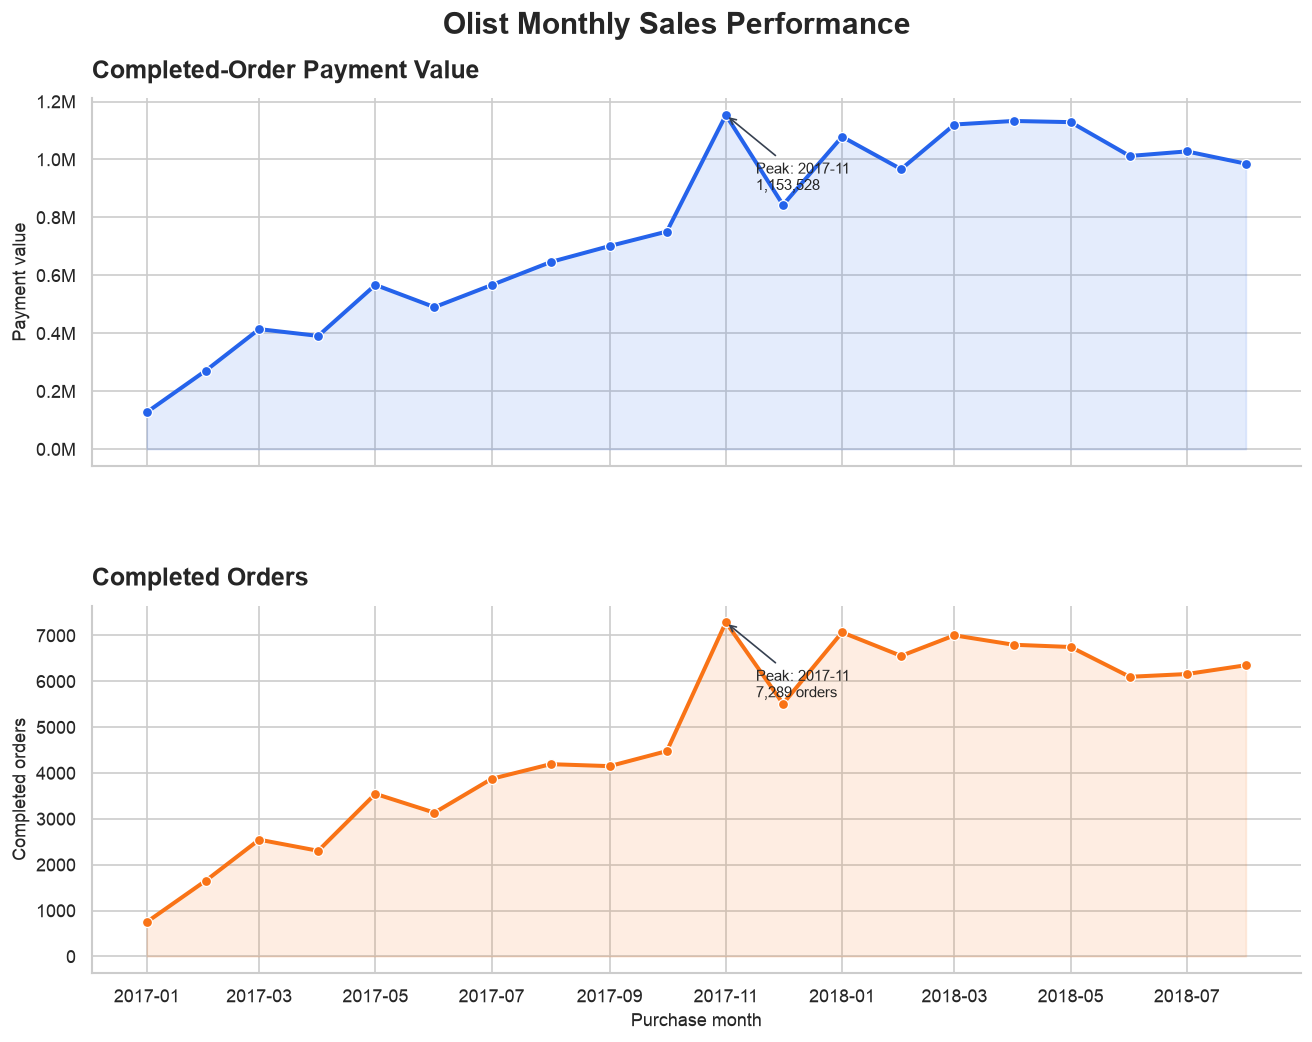

Saved: /Users/liyang/Documents/olist-growth-operations-analytics/visuals/monthly_sales_trend.png


In [3]:
plot_data = monthly_sales[
    monthly_sales["sales_month"] >= "2017-01-01"
].copy()

peak_sales = plot_data.loc[
    plot_data["payment_value_total"].idxmax()
]

peak_orders = plot_data.loc[
    plot_data["order_count"].idxmax()
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 9),
    sharex=True
)

# Payment-value trend
sns.lineplot(
    data=plot_data,
    x="sales_month",
    y="payment_value_total",
    marker="o",
    linewidth=2.4,
    color="#2563EB",
    ax=axes[0]
)

axes[0].fill_between(
    plot_data["sales_month"],
    plot_data["payment_value_total"],
    alpha=0.12,
    color="#2563EB"
)

axes[0].set_title(
    "Completed-Order Payment Value",
    loc="left",
    pad=12
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Payment value")

axes[0].yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value / 1_000_000:.1f}M"
    )
)

axes[0].annotate(
    (
        f"Peak: {peak_sales['sales_month']:%Y-%m}\n"
        f"{peak_sales['payment_value_total']:,.0f}"
    ),
    xy=(
        peak_sales["sales_month"],
        peak_sales["payment_value_total"]
    ),
    xytext=(18, -45),
    textcoords="offset points",
    fontsize=9,
    arrowprops={
        "arrowstyle": "->",
        "color": "#374151"
    }
)

# Completed-order trend
sns.lineplot(
    data=plot_data,
    x="sales_month",
    y="order_count",
    marker="o",
    linewidth=2.4,
    color="#F97316",
    ax=axes[1]
)

axes[1].fill_between(
    plot_data["sales_month"],
    plot_data["order_count"],
    alpha=0.12,
    color="#F97316"
)

axes[1].set_title(
    "Completed Orders",
    loc="left",
    pad=12
)

axes[1].set_xlabel("Purchase month")
axes[1].set_ylabel("Completed orders")

axes[1].annotate(
    (
        f"Peak: {peak_orders['sales_month']:%Y-%m}\n"
        f"{peak_orders['order_count']:,.0f} orders"
    ),
    xy=(
        peak_orders["sales_month"],
        peak_orders["order_count"]
    ),
    xytext=(18, -45),
    textcoords="offset points",
    fontsize=9,
    arrowprops={
        "arrowstyle": "->",
        "color": "#374151"
    }
)

for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

fig.suptitle(
    "Olist Monthly Sales Performance",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.subplots_adjust(
    top=0.90,
    bottom=0.09,
    hspace=0.38
)

output_path = VISUAL_DIR / "monthly_sales_trend.png"

fig.savefig(
    output_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", output_path)

## 2. Customer Growth

This section tracks monthly active customers and their month-over-month growth rate.

The customer base expanded rapidly during 2017. November 2017 recorded approximately 7,430 active customers, including 7,304 new customers and 126 returning customers.

Growth became less consistent during 2018, with both positive and negative months. The large proportion of new customers indicates that marketplace activity was driven primarily by customer acquisition rather than repeat purchasing.

In [4]:
monthly_customers = pd.read_csv(
    REPORT_DIR / "monthly_customer_growth.csv",
    parse_dates=["activity_month"]
)

monthly_customers = monthly_customers.sort_values(
    "activity_month"
).reset_index(drop=True)

display(monthly_customers.head())

print("Shape:", monthly_customers.shape)
print("Columns:")
print(monthly_customers.columns.tolist())

,activity_month,active_customer_count,new_customer_count,returning_customer_count,order_count,payment_value,previous_active_customer_count,previous_new_customer_count,previous_payment_value,active_customer_growth_pct,new_customer_growth_pct,payment_growth_pct
0,2016-09-01,4,4,0,4,252.24,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-10-01,321,321,0,324,59090.48,4.0,4.0,252.24,7925.0,7925.0,23326.29
2,2016-11-01,0,0,0,0,0.00,321.0,321.0,59090.48,-100.0,-100.0,-100.00
3,2016-12-01,1,1,0,1,19.62,0.0,0.0,0.00,NaN,NaN,NaN
4,2017-01-01,765,764,1,800,138488.04,1.0,1.0,19.62,76400.0,76300.0,705751.38


Shape: (26, 12)
Columns:
['activity_month', 'active_customer_count', 'new_customer_count', 'returning_customer_count', 'order_count', 'payment_value', 'previous_active_customer_count', 'previous_new_customer_count', 'previous_payment_value', 'active_customer_growth_pct', 'new_customer_growth_pct', 'payment_growth_pct']


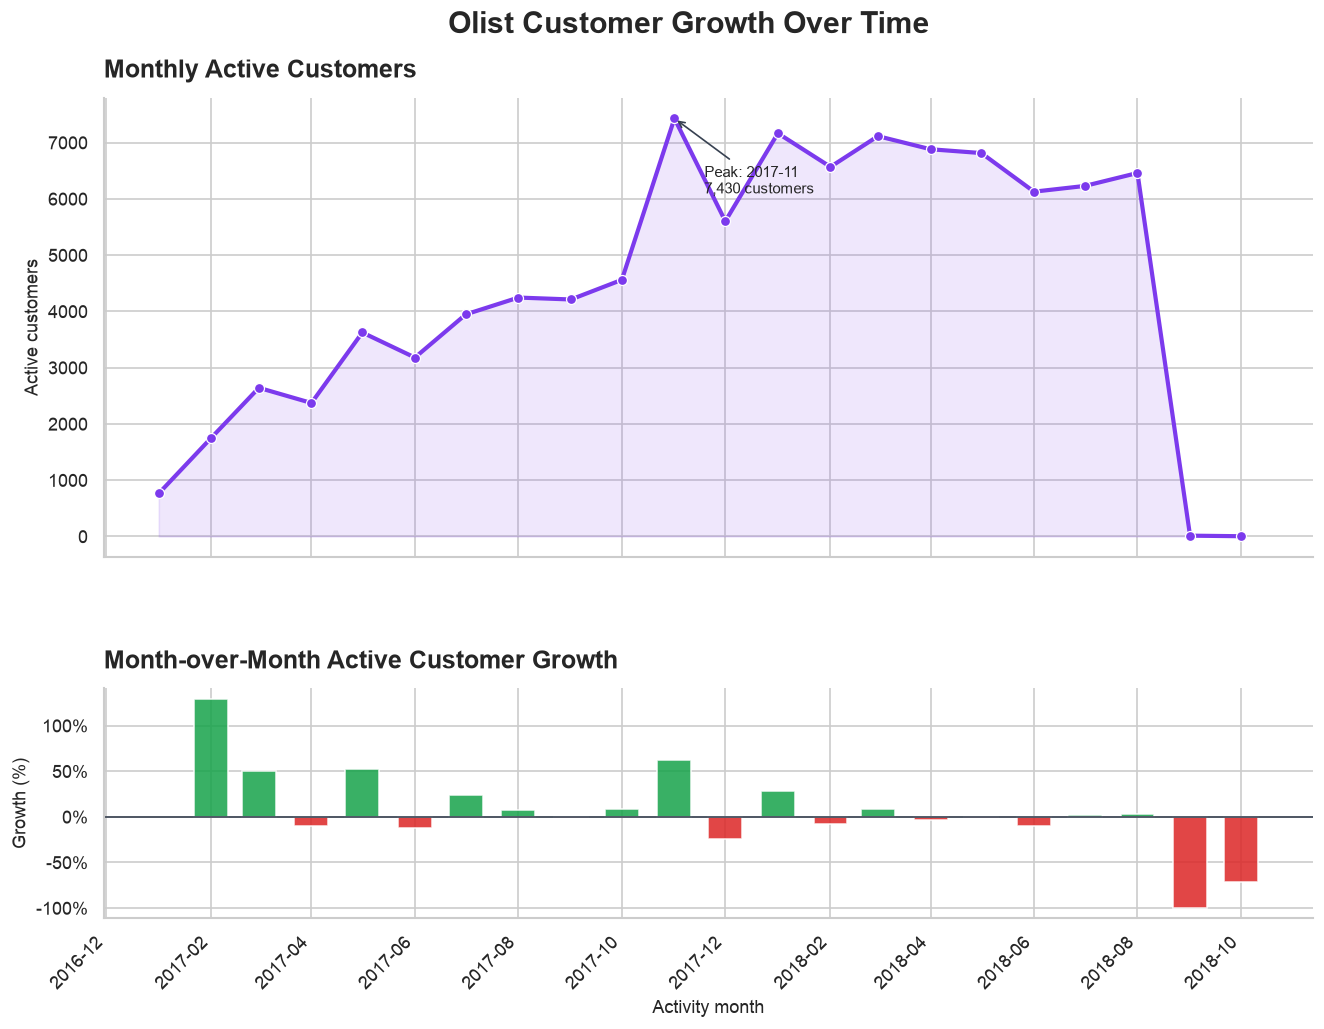

Saved: /Users/liyang/Documents/olist-growth-operations-analytics/visuals/customer_growth_trend.png


In [5]:
import matplotlib.dates as mdates

customer_plot = monthly_customers[
    monthly_customers["activity_month"] >= "2017-01-01"
].copy()

# Exclude the first displayed month from the growth chart
# because its growth rate depends on the previous partial month.
growth_plot = customer_plot.iloc[1:].copy()

growth_plot["growth_color"] = growth_plot[
    "active_customer_growth_pct"
].apply(
    lambda value: "#16A34A" if value >= 0 else "#DC2626"
)

peak_customers = customer_plot.loc[
    customer_plot["active_customer_count"].idxmax()
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 9),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1]
    }
)

# Active-customer trend
sns.lineplot(
    data=customer_plot,
    x="activity_month",
    y="active_customer_count",
    marker="o",
    linewidth=2.5,
    color="#7C3AED",
    ax=axes[0]
)

axes[0].fill_between(
    customer_plot["activity_month"],
    customer_plot["active_customer_count"],
    alpha=0.12,
    color="#7C3AED"
)

axes[0].set_title(
    "Monthly Active Customers",
    loc="left",
    pad=12
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Active customers")

axes[0].annotate(
    (
        f"Peak: {peak_customers['activity_month']:%Y-%m}\n"
        f"{peak_customers['active_customer_count']:,.0f} customers"
    ),
    xy=(
        peak_customers["activity_month"],
        peak_customers["active_customer_count"]
    ),
    xytext=(18, -45),
    textcoords="offset points",
    fontsize=9,
    arrowprops={
        "arrowstyle": "->",
        "color": "#374151"
    }
)

# Month-over-month growth
axes[1].bar(
    growth_plot["activity_month"],
    growth_plot["active_customer_growth_pct"],
    width=20,
    color=growth_plot["growth_color"],
    alpha=0.85
)

axes[1].axhline(
    y=0,
    color="#374151",
    linewidth=1
)

axes[1].set_title(
    "Month-over-Month Active Customer Growth",
    loc="left",
    pad=12
)

axes[1].set_xlabel("Activity month")
axes[1].set_ylabel("Growth (%)")

axes[1].yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.0f}%"
    )
)

axes[1].xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.setp(
    axes[1].get_xticklabels(),
    rotation=45,
    ha="right"
)

for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

fig.suptitle(
    "Olist Customer Growth Over Time",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.subplots_adjust(
    top=0.90,
    bottom=0.14,
    hspace=0.38
)

output_path = VISUAL_DIR / "customer_growth_trend.png"

fig.savefig(
    output_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", output_path)

## 3. Customer Cohort Retention

Customers are grouped by the month of their first completed purchase. Each heatmap cell shows the percentage of a cohort that returned in a later month.

Month 0 is excluded because it represents the acquisition month and therefore has 100% retention by definition.

Retention falls sharply after the initial purchase. The weighted Month 1 retention rate is approximately 0.48%, indicating that only a small proportion of customers made another purchase in the following month.

Later cohorts have fewer observable months, producing the triangular pattern of missing cells on the right side of the heatmap.

In [6]:
cohort_retention = pd.read_csv(
    REPORT_DIR / "cohort_retention_matrix_12m.csv",
    parse_dates=["cohort_month"]
)

cohort_retention = cohort_retention.sort_values(
    "cohort_month"
).reset_index(drop=True)

display(cohort_retention.head())

print("Shape:", cohort_retention.shape)
print("Columns:")
print(cohort_retention.columns.tolist())

,cohort_month,cohort_size,month_0,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2016-09-01,4,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2016-10-01,321,100.0,0.00,0.00,0.00,0.00,0.00,0.31,0.00,0.00,0.31,0.00,0.31,0.00
2,2016-12-01,1,100.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,2017-01-01,764,100.0,0.39,0.26,0.13,0.39,0.13,0.52,0.13,0.13,0.00,0.39,0.13,0.79
4,2017-02-01,1752,100.0,0.23,0.29,0.11,0.40,0.11,0.23,0.17,0.17,0.23,0.11,0.29,0.17


Shape: (25, 15)
Columns:
['cohort_month', 'cohort_size', 'month_0', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']


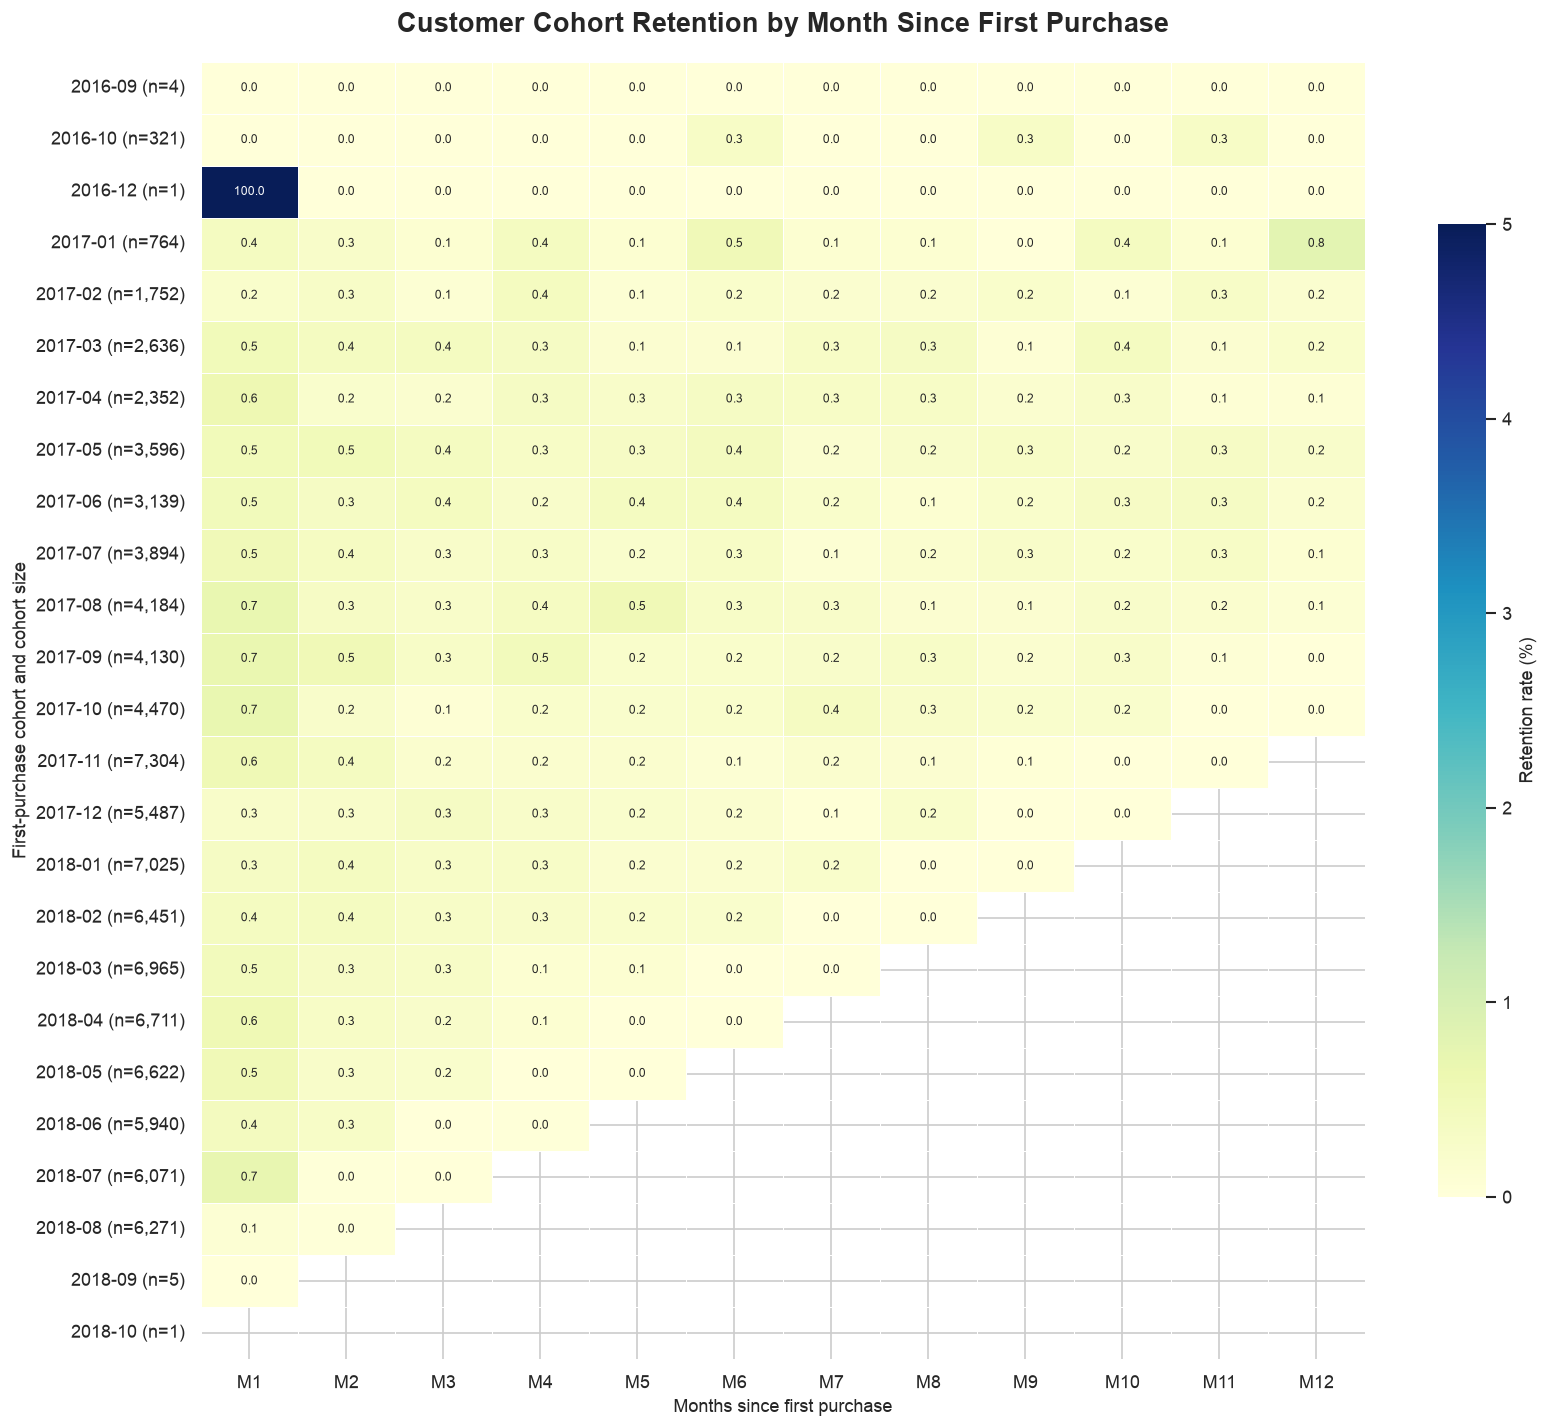

Heatmap colour maximum: 5.0
Saved: /Users/liyang/Documents/olist-growth-operations-analytics/visuals/cohort_retention_heatmap.png


In [7]:
# Detect and correctly order the month columns.
month_columns = sorted(
    [
        column
        for column in cohort_retention.columns
        if column.startswith("month_")
    ],
    key=lambda column: int(column.split("_")[1])
)

# Exclude month 0 because it is always the acquisition month
# and therefore normally has 100% retention.
retention_columns = [
    column
    for column in month_columns
    if column != "month_0"
]

retention_matrix = (
    cohort_retention
    .set_index("cohort_month")[retention_columns]
    .apply(pd.to_numeric, errors="coerce")
)

# Support either decimal retention values or percentage values.
if retention_matrix.max().max() <= 1:
    retention_matrix = retention_matrix * 100

cohort_sizes = (
    cohort_retention
    .set_index("cohort_month")["cohort_size"]
)

retention_matrix.index = [
    (
        f"{cohort_month:%Y-%m} "
        f"(n={int(cohort_sizes.loc[cohort_month]):,})"
    )
    for cohort_month in retention_matrix.index
]

retention_matrix.columns = [
    f"M{int(column.split('_')[1])}"
    for column in retention_matrix.columns
]

# Prevent unusually high values from hiding differences
# among the majority of cohorts.
non_null_values = retention_matrix.stack()

heatmap_max = min(
    max(non_null_values.quantile(0.95), 5.0),
    20.0
)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    retention_matrix,
    mask=retention_matrix.isna(),
    cmap="YlGnBu",
    vmin=0,
    vmax=heatmap_max,
    annot=True,
    fmt=".1f",
    annot_kws={"fontsize": 7},
    linewidths=0.4,
    linecolor="white",
    cbar_kws={
        "label": "Retention rate (%)",
        "shrink": 0.75
    },
    ax=ax
)

ax.set_title(
    "Customer Cohort Retention by Month Since First Purchase",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Months since first purchase")
ax.set_ylabel("First-purchase cohort and cohort size")

plt.yticks(rotation=0)
plt.xticks(rotation=0)

fig.tight_layout()

output_path = (
    VISUAL_DIR / "cohort_retention_heatmap.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Heatmap colour maximum:", round(heatmap_max, 2))
print("Saved:", output_path)

## 4. RFM Customer Segmentation

RFM segmentation evaluates customers using:

- **Recency:** How recently the customer purchased
- **Frequency:** How often the customer purchased
- **Monetary value:** How much the customer spent

The largest segment is `Hibernating`, containing 33,363 customers. Another 21,677 customers belong to `High Value at Risk`.

The project also identifies small but commercially important groups such as `Champions` and `Loyal Customers`. These groups have relatively high average customer value but represent a very small share of the customer base.

The segment definitions are business rules designed for prioritisation and should not be interpreted as permanent customer characteristics.

In [8]:
rfm_segments = pd.read_csv(
    REPORT_DIR / "customer_segment_summary.csv"
)

display(rfm_segments)

print("Shape:", rfm_segments.shape)
print("Columns:")
print(rfm_segments.columns.tolist())

,customer_segment,customer_count,customer_share_pct,completed_order_count,monetary_value,average_recency_days,average_completed_orders,average_customer_value
0,High Value at Risk,21677,22.56,23022,6538599.45,337.01,1.06,301.64
1,Need Attention,19521,20.31,20074,3304202.49,136.62,1.03,169.26
2,Hibernating,33363,34.72,33363,2417915.65,339.74,1.00,72.47
3,Promising,11365,11.83,11365,1898661.33,60.23,1.00,167.06
4,New Customers,6414,6.67,6414,1000651.11,18.60,1.00,156.01
5,Potential Loyalists,552,0.57,1104,160449.92,46.39,2.00,290.67
6,Champions,55,0.06,206,36095.89,45.44,3.75,656.29
7,At Risk,340,0.35,696,33598.37,338.76,2.05,98.82
8,Loyal Customers,70,0.07,233,32287.56,129.74,3.33,461.25
9,No Completed Purchase,2739,2.85,0,0.00,NaN,0.00,0.00


Shape: (10, 8)
Columns:
['customer_segment', 'customer_count', 'customer_share_pct', 'completed_order_count', 'monetary_value', 'average_recency_days', 'average_completed_orders', 'average_customer_value']


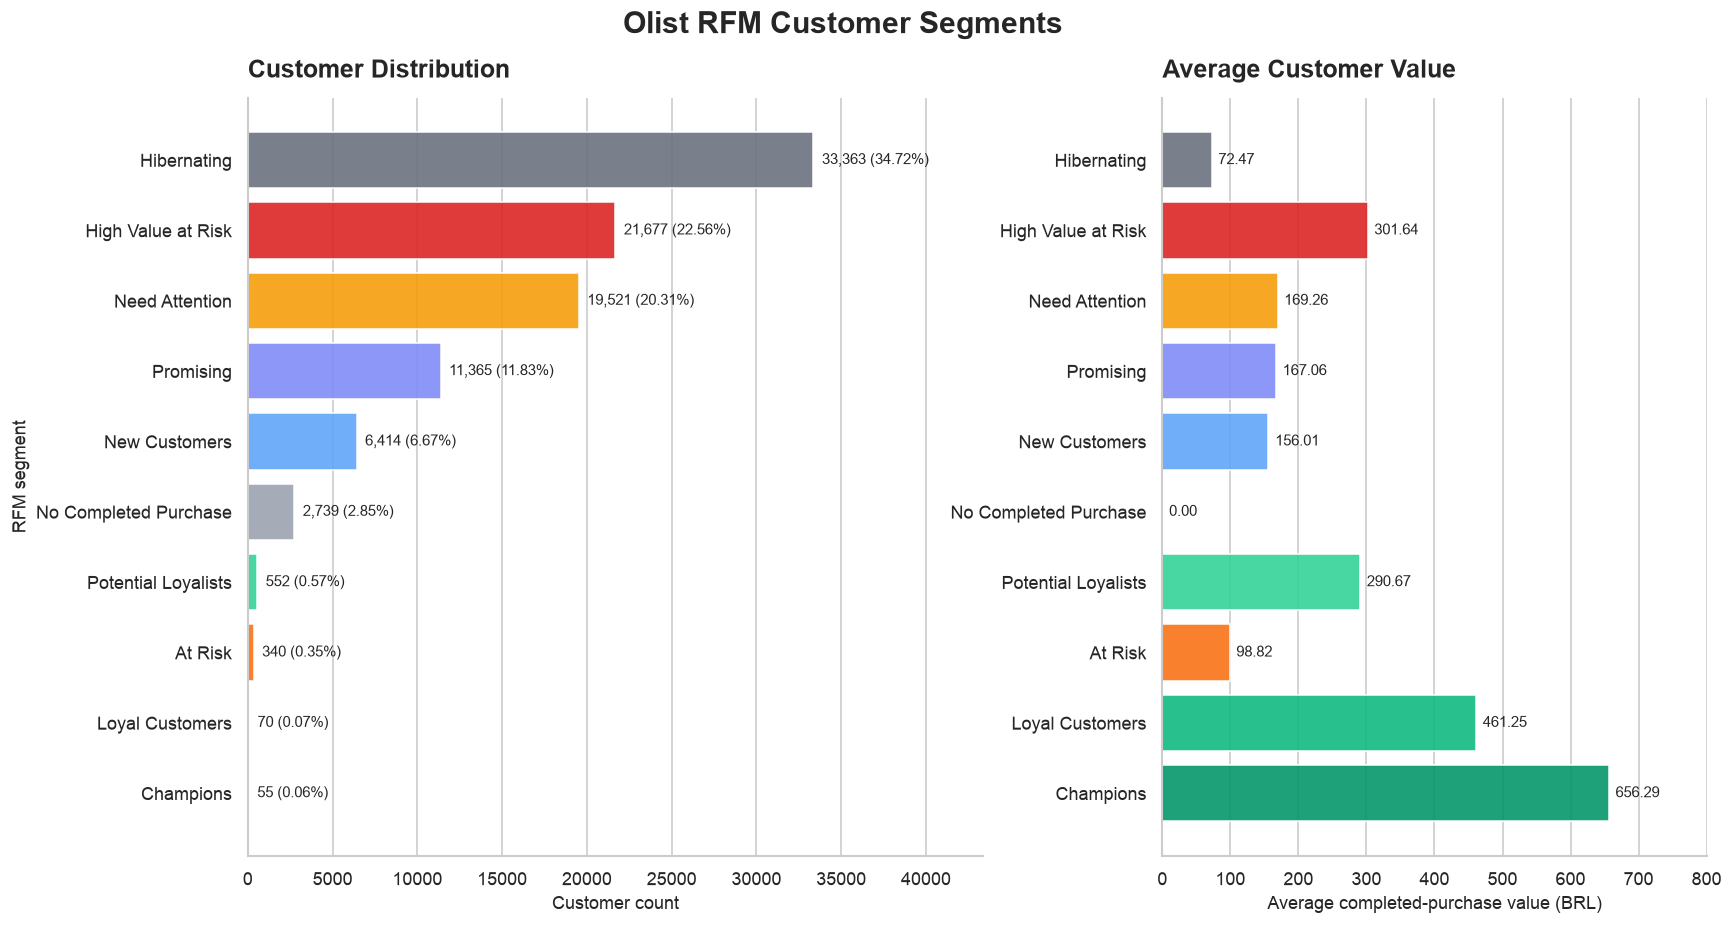

Saved: /Users/liyang/Documents/olist-growth-operations-analytics/visuals/rfm_segment_distribution.png


In [9]:
segment_plot = rfm_segments.sort_values(
    "customer_count",
    ascending=True
).copy()

segment_colors = {
    "Champions": "#059669",
    "Loyal Customers": "#10B981",
    "Potential Loyalists": "#34D399",
    "New Customers": "#60A5FA",
    "Promising": "#818CF8",
    "Need Attention": "#F59E0B",
    "High Value at Risk": "#DC2626",
    "At Risk": "#F97316",
    "Hibernating": "#6B7280",
    "No Completed Purchase": "#9CA3AF"
}

bar_colors = [
    segment_colors.get(segment, "#64748B")
    for segment in segment_plot["customer_segment"]
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 8),
    gridspec_kw={
        "width_ratios": [1.35, 1]
    }
)

# Customer-count chart
axes[0].barh(
    segment_plot["customer_segment"],
    segment_plot["customer_count"],
    color=bar_colors,
    alpha=0.9
)

axes[0].set_title(
    "Customer Distribution",
    loc="left",
    pad=12
)

axes[0].set_xlabel("Customer count")
axes[0].set_ylabel("RFM segment")

maximum_customer_count = segment_plot[
    "customer_count"
].max()

for index, row in segment_plot.reset_index(drop=True).iterrows():
    axes[0].text(
        row["customer_count"] + maximum_customer_count * 0.015,
        index,
        (
            f"{row['customer_count']:,.0f} "
            f"({row['customer_share_pct']:.2f}%)"
        ),
        va="center",
        fontsize=9
    )

axes[0].set_xlim(
    0,
    maximum_customer_count * 1.30
)

# Average-customer-value chart
axes[1].barh(
    segment_plot["customer_segment"],
    segment_plot["average_customer_value"],
    color=bar_colors,
    alpha=0.9
)

axes[1].set_title(
    "Average Customer Value",
    loc="left",
    pad=12
)

axes[1].set_xlabel("Average completed-purchase value (BRL)")
axes[1].set_ylabel("")

maximum_customer_value = segment_plot[
    "average_customer_value"
].max()

for index, row in segment_plot.reset_index(drop=True).iterrows():
    axes[1].text(
        row["average_customer_value"]
        + maximum_customer_value * 0.015,
        index,
        f"{row['average_customer_value']:,.2f}",
        va="center",
        fontsize=9
    )

axes[1].set_xlim(
    0,
    maximum_customer_value * 1.22
)

for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(axis="y", visible=False)

fig.suptitle(
    "Olist RFM Customer Segments",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.subplots_adjust(
    top=0.89,
    bottom=0.10,
    left=0.19,
    right=0.95,
    wspace=0.28
)

output_path = (
    VISUAL_DIR / "rfm_segment_distribution.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", output_path)

## 5. Product-Category Performance

This section compares the leading product categories by item revenue and freight share.

The highest-revenue categories are:

1. `health_beauty`
2. `watches_gifts`
3. `bed_bath_table`
4. `sports_leisure`
5. `computers_accessories`

`health_beauty` contributes approximately 9.33% of total item revenue. The category mix is concentrated but not dominated by a single category.

Freight share differs across categories and may reflect product size, weight, seller location and customer distance. Revenue should not be interpreted as profit because the dataset does not contain product costs, platform commissions or operating expenses.

In [10]:
category_performance = pd.read_csv(
    REPORT_DIR / "category_performance.csv"
)

display(category_performance.head())

print("Shape:", category_performance.shape)
print("Columns:")
print(category_performance.columns.tolist())

,product_category_name_english,order_count,item_count,product_count,seller_count,customer_count,item_price_total,freight_total,item_and_freight_total,average_item_price,average_items_per_order,freight_share_pct,item_revenue_share_pct,item_revenue_rank
0,health_beauty,8646,9462,2397,479,8497,1232996.75,178949.32,1411946.07,130.31,1.09,12.67,9.33,1
1,watches_gifts,5495,5859,1300,95,5421,1166176.98,98156.14,1264333.12,199.04,1.07,7.76,8.82,2
2,bed_bath_table,9272,10953,2991,189,9008,1023434.76,201774.50,1225209.26,93.44,1.18,16.47,7.74,3
3,sports_leisure,7530,8431,2822,466,7341,954852.55,163404.36,1118256.91,113.25,1.12,14.61,7.22,4
4,computers_accessories,6530,7644,1600,279,6405,888724.61,143999.16,1032723.77,116.26,1.17,13.94,6.72,5


Shape: (74, 14)
Columns:
['product_category_name_english', 'order_count', 'item_count', 'product_count', 'seller_count', 'customer_count', 'item_price_total', 'freight_total', 'item_and_freight_total', 'average_item_price', 'average_items_per_order', 'freight_share_pct', 'item_revenue_share_pct', 'item_revenue_rank']


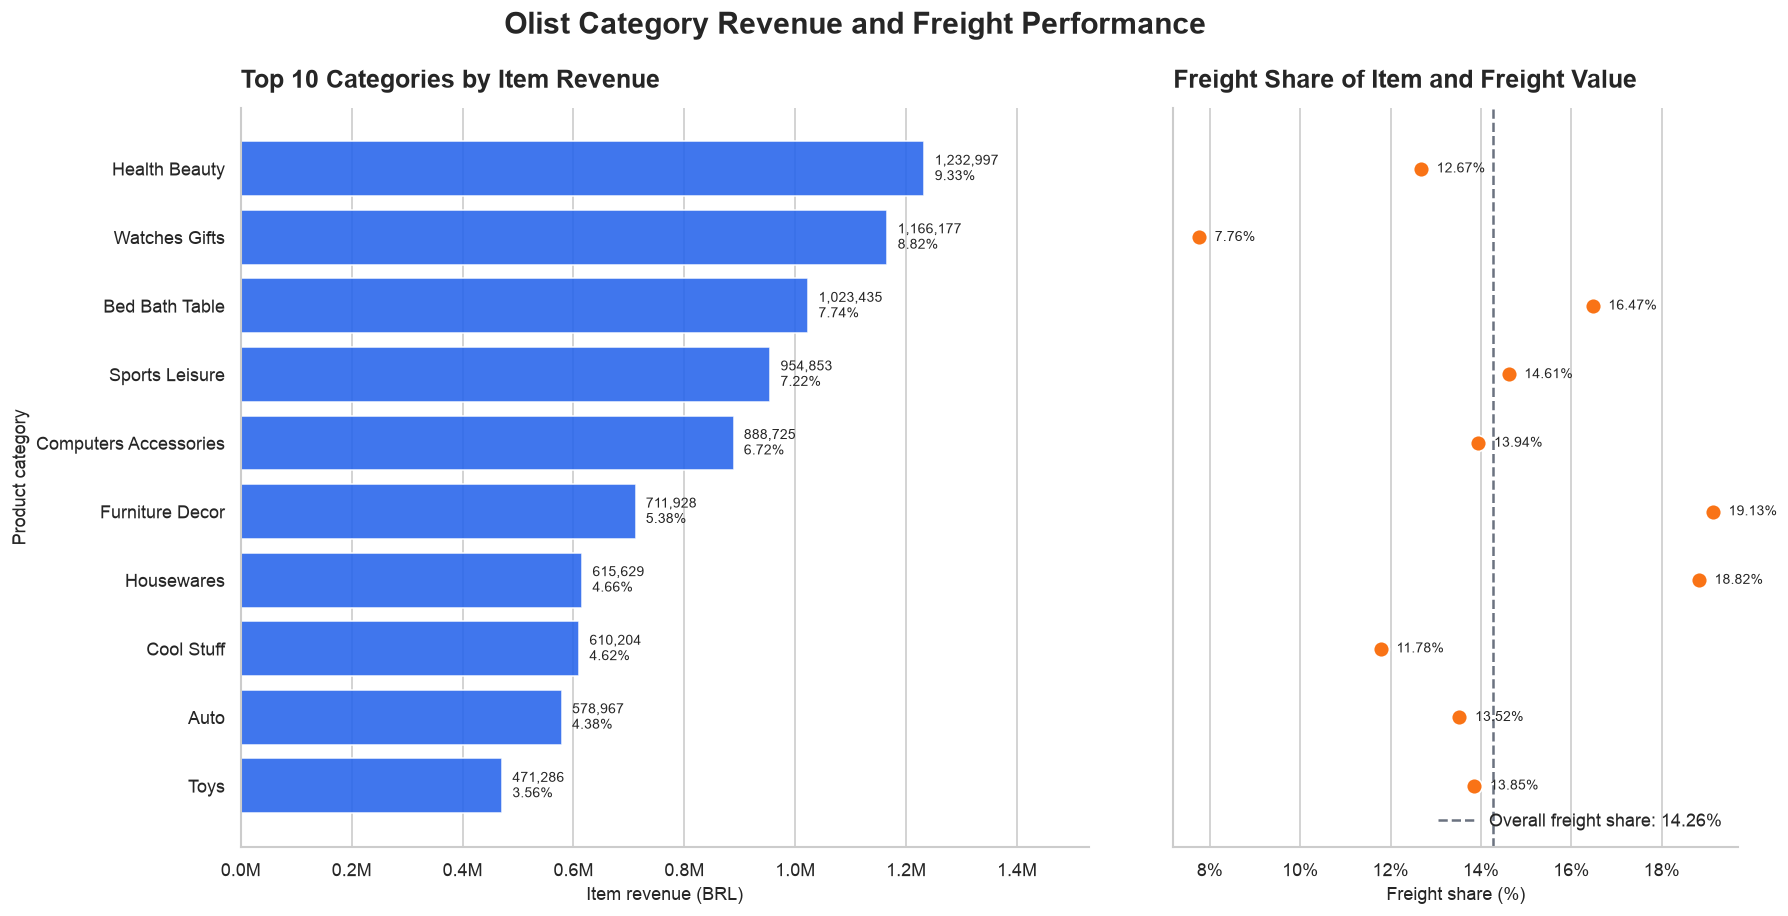

Overall freight share: 14.26
Saved: /Users/liyang/Documents/olist-growth-operations-analytics/visuals/category_revenue_performance.png


In [11]:
category_plot = (
    category_performance
    .nlargest(10, "item_price_total")
    .sort_values("item_price_total")
    .copy()
)

category_plot["category_label"] = (
    category_plot["product_category_name_english"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

overall_freight_share = (
    100
    * category_performance["freight_total"].sum()
    / (
        category_performance["item_price_total"].sum()
        + category_performance["freight_total"].sum()
    )
)

positions = range(len(category_plot))

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 8),
    sharey=True,
    gridspec_kw={
        "width_ratios": [1.5, 1]
    }
)

# Revenue bars
bars = axes[0].barh(
    positions,
    category_plot["item_price_total"],
    color="#2563EB",
    alpha=0.88
)

axes[0].set_yticks(
    list(positions),
    labels=category_plot["category_label"]
)

axes[0].set_title(
    "Top 10 Categories by Item Revenue",
    loc="left",
    pad=12
)

axes[0].set_xlabel("Item revenue (BRL)")
axes[0].set_ylabel("Product category")

axes[0].xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value / 1_000_000:.1f}M"
    )
)

maximum_revenue = category_plot[
    "item_price_total"
].max()

for bar, (_, row) in zip(
    bars,
    category_plot.iterrows()
):
    axes[0].text(
        bar.get_width() + maximum_revenue * 0.015,
        bar.get_y() + bar.get_height() / 2,
        (
            f"{row['item_price_total']:,.0f}\n"
            f"{row['item_revenue_share_pct']:.2f}%"
        ),
        va="center",
        fontsize=8.5
    )

axes[0].set_xlim(
    0,
    maximum_revenue * 1.24
)

# Freight-share comparison
axes[1].scatter(
    category_plot["freight_share_pct"],
    list(positions),
    s=90,
    color="#F97316",
    edgecolor="white",
    linewidth=1,
    zorder=3
)

axes[1].axvline(
    overall_freight_share,
    color="#6B7280",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall freight share: "
        f"{overall_freight_share:.2f}%"
    )
)

axes[1].set_title(
    "Freight Share of Item and Freight Value",
    loc="left",
    pad=12
)

axes[1].set_xlabel("Freight share (%)")
axes[1].set_ylabel("")

axes[1].xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.0f}%"
    )
)

for position, (_, row) in zip(
    positions,
    category_plot.iterrows()
):
    axes[1].text(
        row["freight_share_pct"] + 0.35,
        position,
        f"{row['freight_share_pct']:.2f}%",
        va="center",
        fontsize=8.5
    )

axes[1].legend(
    loc="lower right",
    frameon=False
)

for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(axis="y", visible=False)

fig.suptitle(
    "Olist Category Revenue and Freight Performance",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.subplots_adjust(
    top=0.88,
    bottom=0.11,
    left=0.18,
    right=0.96,
    wspace=0.12
)

output_path = (
    VISUAL_DIR / "category_revenue_performance.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Overall freight share:", round(overall_freight_share, 2))
print("Saved:", output_path)

## 6. Delivery Performance and Customer Reviews

This section compares valid delivery orders classified as either `Late` or `On Time or Early`.

Late orders took an average of 33.91 days to arrive, compared with 10.99 days for on-time or early orders.

Late orders had:

- An average review score of 2.27
- A low-review rate of 62.41%
- A written-comment rate of 58.90%

On-time or early orders had:

- An average review score of 4.29
- A low-review rate of 9.22%
- A written-comment rate of 39.34%

These results show a strong association between delivery delays and customer dissatisfaction. They do not, by themselves, prove causation.

In [12]:
delivery_review = pd.read_csv(
    REPORT_DIR / "delivery_review_impact.csv"
)

delivery_order = [
    "On Time or Early",
    "Late"
]

delivery_review["delivery_status"] = pd.Categorical(
    delivery_review["delivery_status"],
    categories=delivery_order,
    ordered=True
)

delivery_review = (
    delivery_review
    .sort_values("delivery_status")
    .reset_index(drop=True)
)

display(delivery_review)

print("Shape:", delivery_review.shape)
print("Columns:")
print(delivery_review.columns.tolist())

,delivery_status,order_count,reviewed_order_count,average_delivery_days,average_delivery_delay_days,average_review_score,low_review_order_count,low_review_rate_pct,written_comment_order_count,written_comment_rate_pct
0,On Time or Early,88587,88101,10.99,-13.48,4.29,8127,9.22,34655,39.34
1,Late,6509,6356,33.91,10.62,2.27,3967,62.41,3744,58.90


Shape: (2, 10)
Columns:
['delivery_status', 'order_count', 'reviewed_order_count', 'average_delivery_days', 'average_delivery_delay_days', 'average_review_score', 'low_review_order_count', 'low_review_rate_pct', 'written_comment_order_count', 'written_comment_rate_pct']


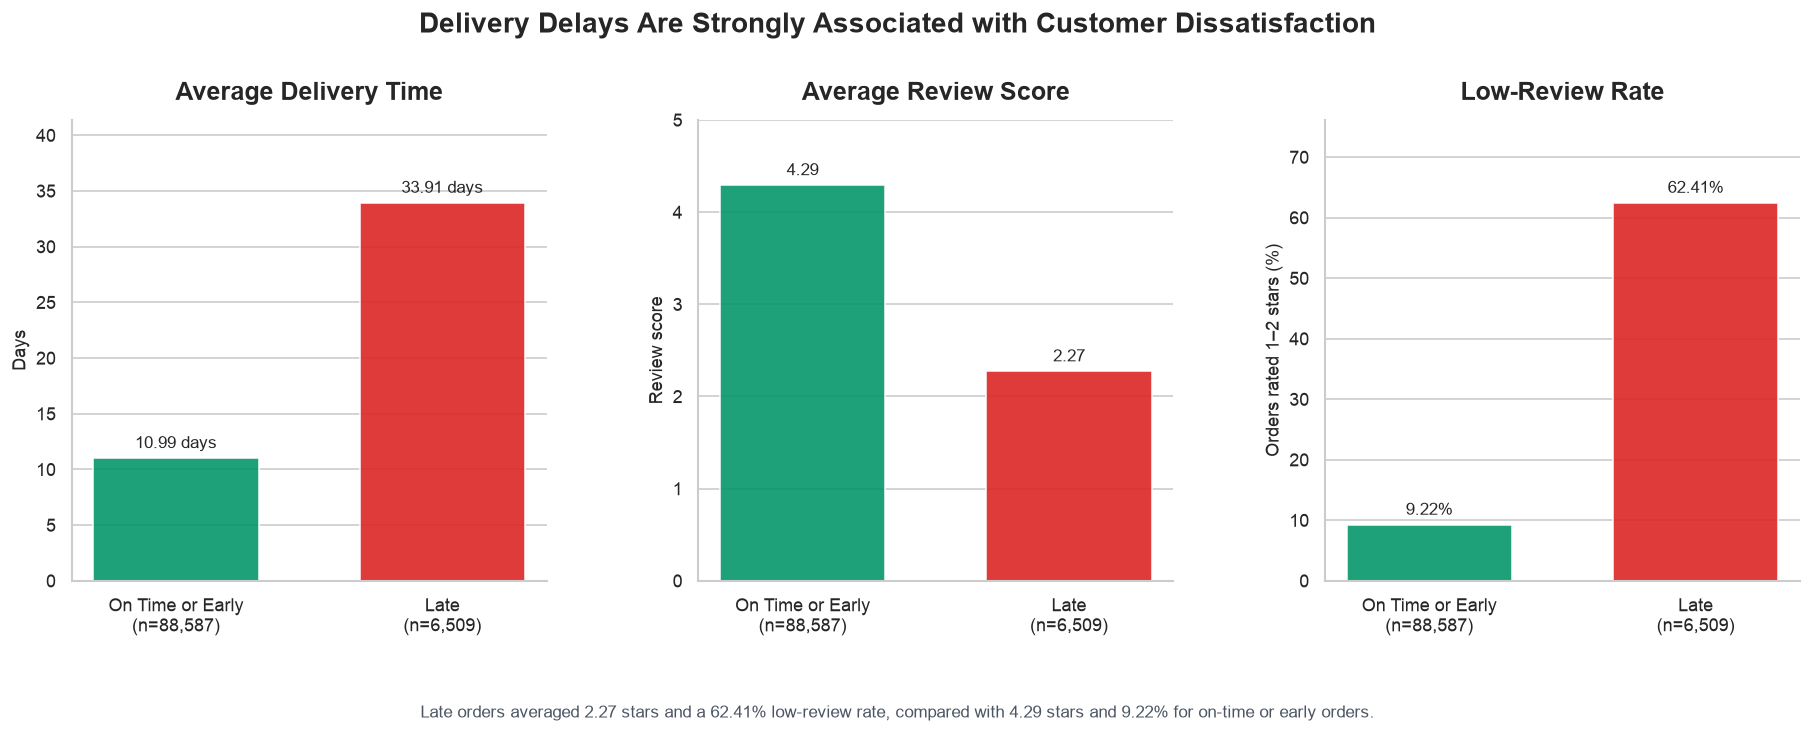

Saved: /Users/liyang/Documents/olist-growth-operations-analytics/visuals/delivery_review_comparison.png


In [13]:
status_colors = {
    "On Time or Early": "#059669",
    "Late": "#DC2626"
}

colors = [
    status_colors[str(status)]
    for status in delivery_review["delivery_status"]
]

status_labels = [
    (
        f"{status}\n"
        f"(n={order_count:,.0f})"
    )
    for status, order_count in zip(
        delivery_review["delivery_status"],
        delivery_review["order_count"]
    )
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 6)
)

# Average delivery duration
bars_delivery = axes[0].bar(
    status_labels,
    delivery_review["average_delivery_days"],
    color=colors,
    width=0.62,
    alpha=0.9
)

axes[0].set_title(
    "Average Delivery Time",
    pad=12
)

axes[0].set_ylabel("Days")
axes[0].set_ylim(
    0,
    delivery_review["average_delivery_days"].max() * 1.22
)

axes[0].bar_label(
    bars_delivery,
    labels=[
        f"{value:.2f} days"
        for value in delivery_review[
            "average_delivery_days"
        ]
    ],
    padding=4,
    fontsize=10
)

# Average review score
bars_review = axes[1].bar(
    status_labels,
    delivery_review["average_review_score"],
    color=colors,
    width=0.62,
    alpha=0.9
)

axes[1].set_title(
    "Average Review Score",
    pad=12
)

axes[1].set_ylabel("Review score")
axes[1].set_ylim(0, 5)

axes[1].bar_label(
    bars_review,
    labels=[
        f"{value:.2f}"
        for value in delivery_review[
            "average_review_score"
        ]
    ],
    padding=4,
    fontsize=10
)

# Low-review rate
bars_low_review = axes[2].bar(
    status_labels,
    delivery_review["low_review_rate_pct"],
    color=colors,
    width=0.62,
    alpha=0.9
)

axes[2].set_title(
    "Low-Review Rate",
    pad=12
)

axes[2].set_ylabel("Orders rated 1–2 stars (%)")
axes[2].set_ylim(
    0,
    delivery_review["low_review_rate_pct"].max() * 1.22
)

axes[2].bar_label(
    bars_low_review,
    labels=[
        f"{value:.2f}%"
        for value in delivery_review[
            "low_review_rate_pct"
        ]
    ],
    padding=4,
    fontsize=10
)

for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(axis="x", visible=False)
    axis.tick_params(
        axis="x",
        labelrotation=0
    )

fig.suptitle(
    "Delivery Delays Are Strongly Associated with Customer Dissatisfaction",
    fontsize=17,
    fontweight="bold",
    y=0.99
)

fig.text(
    0.5,
    0.01,
    (
        "Late orders averaged 2.27 stars and a 62.41% "
        "low-review rate, compared with 4.29 stars and "
        "9.22% for on-time or early orders."
    ),
    ha="center",
    fontsize=10,
    color="#4B5563"
)

fig.subplots_adjust(
    top=0.84,
    bottom=0.20,
    left=0.07,
    right=0.97,
    wspace=0.32
)

output_path = (
    VISUAL_DIR / "delivery_review_comparison.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", output_path)

## 7. Regional Delivery Performance

The state-level bubble chart combines four operational measures:

- Average delivery time on the horizontal axis
- Late-delivery rate on the vertical axis
- Completed-order volume represented by bubble size
- Average review score represented by colour

São Paulo (`SP`) has the largest order volume but performs better than the marketplace average on both delivery time and late-delivery rate.

States including Alagoas (`AL`), Maranhão (`MA`) and Sergipe (`SE`) experience longer delivery times and higher late-delivery rates.

Regional percentages must be interpreted together with order volume because results from smaller states are more sensitive to a limited number of orders.

In [14]:
state_delivery = pd.read_csv(
    REPORT_DIR / "state_delivery_performance.csv"
)

operations_kpis = pd.read_csv(
    REPORT_DIR / "overall_operations_kpis.csv"
)

display(state_delivery.head())

print("Shape:", state_delivery.shape)
print("Columns:")
print(state_delivery.columns.tolist())

,customer_state,completed_order_count,customer_count,payment_value_total,freight_total,freight_share_pct,valid_delivery_order_count,late_delivery_order_count,late_delivery_rate_pct,average_delivery_days,average_estimated_delivery_days,average_delivery_delay_days,average_delay_days_when_late,reviewed_order_count,average_review_score,low_review_order_count,low_review_rate_pct
0,SP,40500,39155,5770266.19,702061.50,12.17,39907,1813,4.54,8.74,19.78,-11.04,8.33,40272,4.25,4285,10.64
1,RJ,12350,11917,2055690.45,295750.44,14.39,12212,1492,12.22,15.30,26.97,-11.67,13.53,12211,3.97,2234,18.29
2,MG,11354,11001,1819277.61,266409.84,14.65,11189,517,4.62,12.01,25.21,-13.20,8.42,11285,4.19,1321,11.71
3,RS,5345,5168,861802.40,132575.32,15.39,5262,325,6.18,15.33,29.17,-13.84,10.24,5327,4.19,633,11.88
4,PR,4923,4769,781919.55,115645.29,14.79,4842,199,4.11,12.01,25.28,-13.26,8.32,4900,4.24,531,10.84


Shape: (27, 17)
Columns:
['customer_state', 'completed_order_count', 'customer_count', 'payment_value_total', 'freight_total', 'freight_share_pct', 'valid_delivery_order_count', 'late_delivery_order_count', 'late_delivery_rate_pct', 'average_delivery_days', 'average_estimated_delivery_days', 'average_delivery_delay_days', 'average_delay_days_when_late', 'reviewed_order_count', 'average_review_score', 'low_review_order_count', 'low_review_rate_pct']


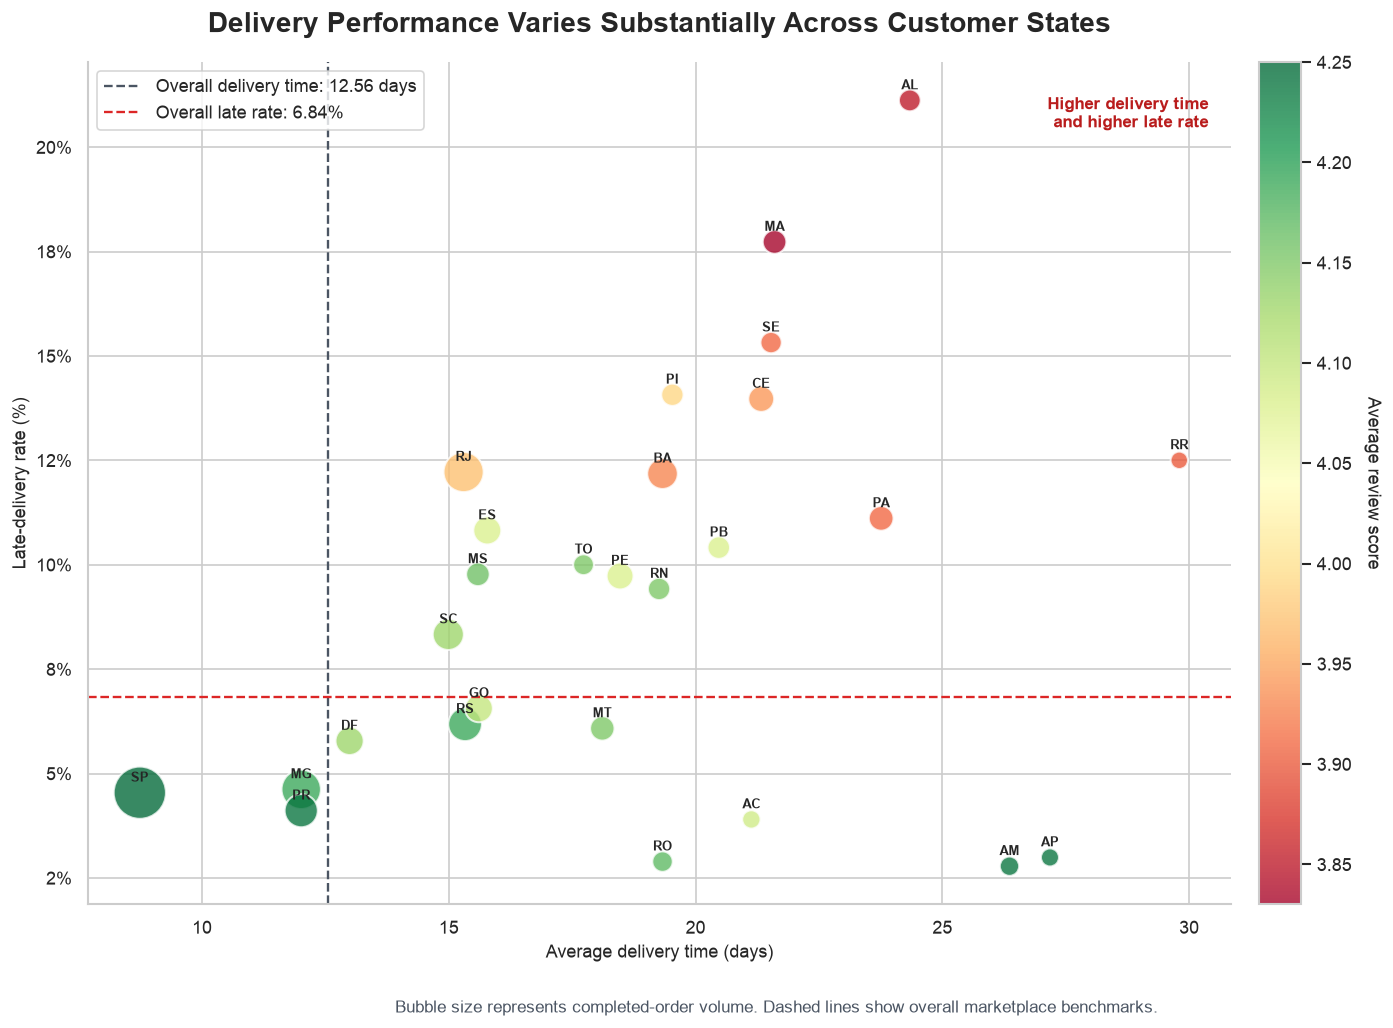

Saved: /Users/liyang/Documents/olist-growth-operations-analytics/visuals/state_delivery_performance.png


In [15]:
import numpy as np

state_plot = state_delivery.dropna(
    subset=[
        "average_delivery_days",
        "late_delivery_rate_pct",
        "average_review_score"
    ]
).copy()

overall_delivery_days = float(
    operations_kpis.loc[
        0,
        "average_delivery_days"
    ]
)

overall_late_rate = float(
    operations_kpis.loc[
        0,
        "late_delivery_rate_pct"
    ]
)

maximum_order_count = state_plot[
    "completed_order_count"
].max()

# Square-root scaling prevents SP from making
# every other state's bubble too small.
state_plot["bubble_size"] = (
    80
    + 900
    * np.sqrt(
        state_plot["completed_order_count"]
        / maximum_order_count
    )
)

fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(
    state_plot["average_delivery_days"],
    state_plot["late_delivery_rate_pct"],
    s=state_plot["bubble_size"],
    c=state_plot["average_review_score"],
    cmap="RdYlGn",
    vmin=state_plot["average_review_score"].min(),
    vmax=state_plot["average_review_score"].max(),
    alpha=0.78,
    edgecolor="white",
    linewidth=1.2
)

# Overall benchmark lines
ax.axvline(
    overall_delivery_days,
    color="#4B5563",
    linestyle="--",
    linewidth=1.4,
    label=(
        f"Overall delivery time: "
        f"{overall_delivery_days:.2f} days"
    )
)

ax.axhline(
    overall_late_rate,
    color="#DC2626",
    linestyle="--",
    linewidth=1.4,
    label=(
        f"Overall late rate: "
        f"{overall_late_rate:.2f}%"
    )
)

# Add state labels
for _, row in state_plot.iterrows():
    ax.annotate(
        row["customer_state"],
        (
            row["average_delivery_days"],
            row["late_delivery_rate_pct"]
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

ax.set_title(
    "Delivery Performance Varies Substantially Across Customer States",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Average delivery time (days)")
ax.set_ylabel("Late-delivery rate (%)")

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.0f}%"
    )
)

ax.text(
    0.98,
    0.96,
    "Higher delivery time\nand higher late rate",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color="#B91C1C",
    fontweight="bold"
)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.02
)

colorbar.set_label(
    "Average review score",
    rotation=270,
    labelpad=18
)

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.02,
    (
        "Bubble size represents completed-order volume. "
        "Dashed lines show overall marketplace benchmarks."
    ),
    ha="center",
    fontsize=10,
    color="#4B5563"
)

fig.subplots_adjust(
    top=0.90,
    bottom=0.12,
    left=0.09,
    right=0.91
)

output_path = (
    VISUAL_DIR / "state_delivery_performance.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", output_path)

## 8. Seller Operational Risk

Seller risk is based on three operational indicators:

- Late-delivery rate
- Shipping-limit breach rate
- Low-review rate

Eligible sellers are assigned quartile scores for each indicator. These scores are combined with item-revenue ranking to create four operational segments.

The analysis identifies:

| Seller segment | Seller count |
|---|---:|
| Stable | 307 |
| Monitor | 300 |
| High Risk | 164 |
| High-Value At Risk | 24 |

The 24 `High-Value At Risk` sellers are the highest operational priority because they combine high commercial value with relatively weak delivery or customer-review performance.

The risk score is a transparent prioritisation rule rather than a predictive probability model.

In [16]:
seller_risk = pd.read_csv(
    REPORT_DIR / "seller_risk.csv"
)

display(seller_risk.head())

print("Shape:", seller_risk.shape)
print("Columns:")
print(seller_risk.columns.tolist())

,seller_id,seller_city,seller_state,completed_order_count,customer_count,item_count,item_price_total,valid_delivery_order_count,late_delivery_rate_pct,average_delivery_days,...,average_review_score,low_review_rate_pct,seller_revenue_rank,seller_revenue_share_pct,late_delivery_quartile,shipping_breach_quartile,low_review_quartile,operational_risk_score,is_high_value_seller,seller_risk_segment
0,1900267e848ceeba8fa32d80c1a5f5a8,ibitinga,SP,406,398,523,24639.57,405,8.15,13.08,...,3.87,18.80,103,0.1864,3,3,4,10,f,High Risk
1,dc4a0fc896dc34b0d5bfec8438291c80,ibitinga,SP,225,224,242,23655.98,225,6.67,13.84,...,3.82,20.44,106,0.1789,3,3,4,10,f,High Risk
2,710e3548e02bc1d2831dfc4f1b5b14d4,rolandia,PR,131,129,137,22369.25,129,3.88,14.57,...,3.43,30.77,112,0.1692,2,4,4,10,f,High Risk
3,7ad32824caee82087b3e2e5f33b1bf32,ibitinga,SP,147,145,180,22018.10,142,13.38,12.20,...,3.86,19.44,114,0.1665,4,2,4,10,f,High Risk
4,897060da8b9a21f655304d50fd935913,ribeirao preto,SP,304,300,413,21740.51,302,10.60,14.89,...,3.71,23.26,117,0.1644,4,3,4,11,f,High Risk


Shape: (795, 22)
Columns:
['seller_id', 'seller_city', 'seller_state', 'completed_order_count', 'customer_count', 'item_count', 'item_price_total', 'valid_delivery_order_count', 'late_delivery_rate_pct', 'average_delivery_days', 'shipping_limit_breach_rate_pct', 'reviewed_order_count', 'average_review_score', 'low_review_rate_pct', 'seller_revenue_rank', 'seller_revenue_share_pct', 'late_delivery_quartile', 'shipping_breach_quartile', 'low_review_quartile', 'operational_risk_score', 'is_high_value_seller', 'seller_risk_segment']


In [17]:
seller_risk["high_value_flag"] = (
    seller_risk["is_high_value_seller"]
    .astype(str)
    .str.lower()
    .isin(["true", "t", "1"])
)

seller_risk_summary = (
    seller_risk
    .groupby(
        "seller_risk_segment",
        as_index=False
    )
    .agg(
        seller_count=(
            "seller_id",
            "nunique"
        ),
        high_value_seller_count=(
            "high_value_flag",
            "sum"
        ),
        item_price_total=(
            "item_price_total",
            "sum"
        ),
        average_late_delivery_rate_pct=(
            "late_delivery_rate_pct",
            "mean"
        ),
        average_low_review_rate_pct=(
            "low_review_rate_pct",
            "mean"
        )
    )
)

risk_order = [
    "Stable",
    "Monitor",
    "High Risk",
    "High-Value At Risk"
]

seller_risk_summary[
    "seller_risk_segment"
] = pd.Categorical(
    seller_risk_summary["seller_risk_segment"],
    categories=risk_order,
    ordered=True
)

seller_risk_summary = (
    seller_risk_summary
    .sort_values("seller_risk_segment")
    .reset_index(drop=True)
)

display(seller_risk_summary)

,seller_risk_segment,seller_count,high_value_seller_count,item_price_total,average_late_delivery_rate_pct,average_low_review_rate_pct
0,Stable,307,26,3051505.95,2.900521,7.450261
1,Monitor,300,49,4940700.56,6.957033,13.339400
2,High Risk,164,0,1274371.18,11.821280,20.587988
3,High-Value At Risk,24,24,1597147.23,11.145000,19.795000


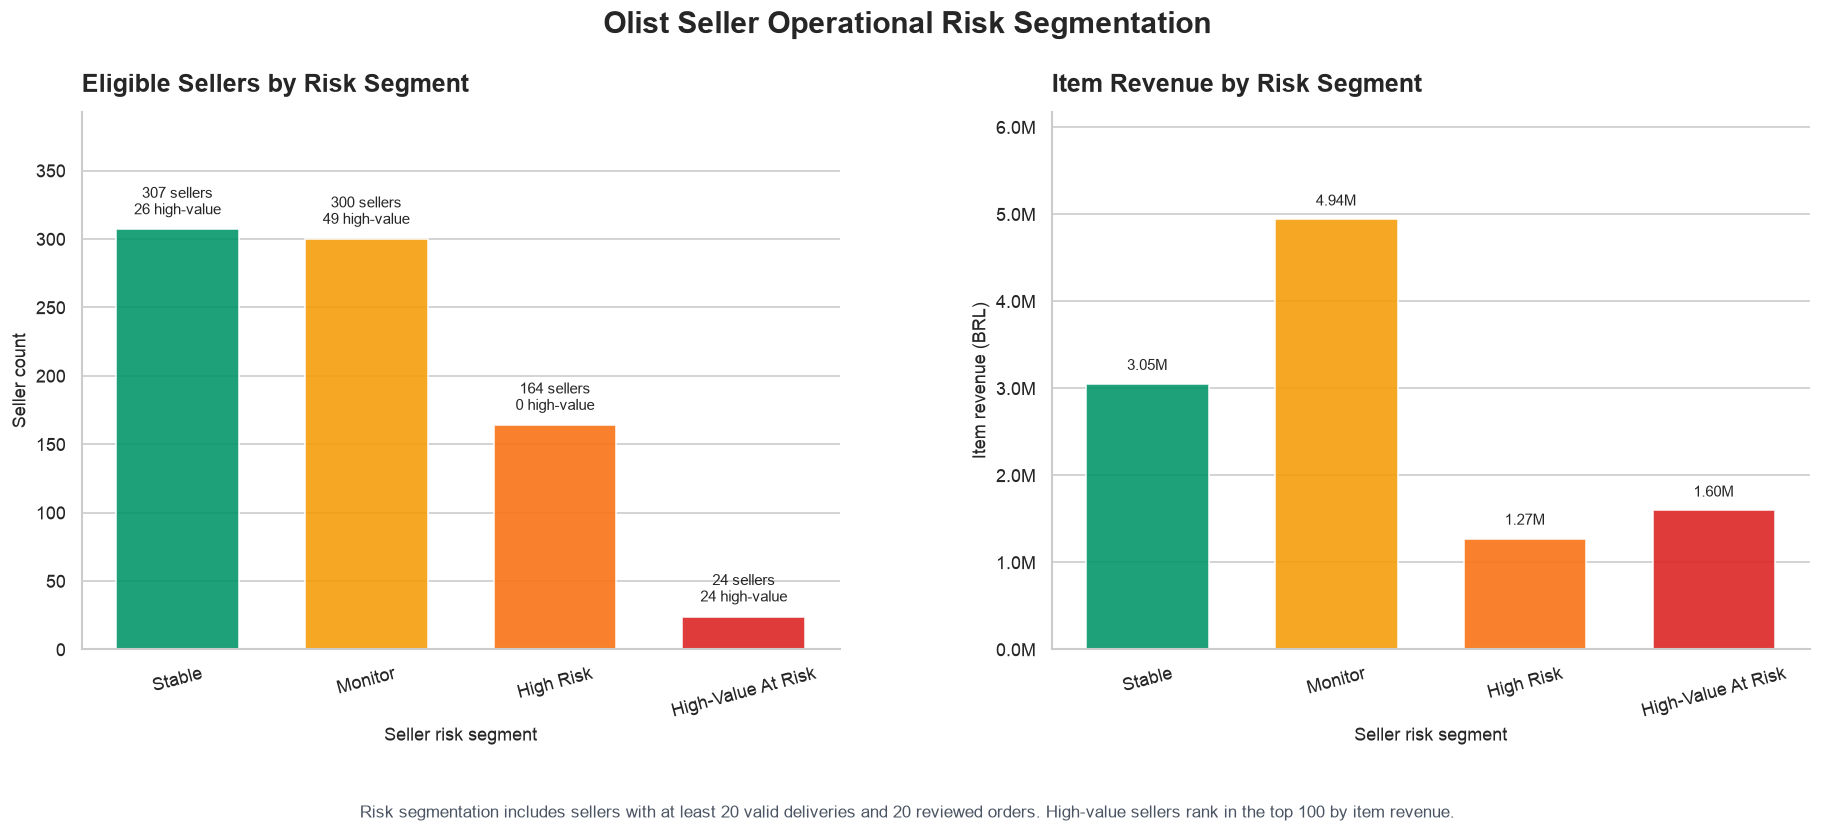

Saved: /Users/liyang/Documents/olist-growth-operations-analytics/visuals/seller_risk_segments.png


In [18]:
risk_colors = {
    "Stable": "#059669",
    "Monitor": "#F59E0B",
    "High Risk": "#F97316",
    "High-Value At Risk": "#DC2626"
}

colors = [
    risk_colors[str(segment)]
    for segment in seller_risk_summary[
        "seller_risk_segment"
    ]
]

segment_labels = [
    str(segment)
    for segment in seller_risk_summary[
        "seller_risk_segment"
    ]
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7)
)

# Seller count
seller_bars = axes[0].bar(
    segment_labels,
    seller_risk_summary["seller_count"],
    color=colors,
    width=0.65,
    alpha=0.9
)

axes[0].set_title(
    "Eligible Sellers by Risk Segment",
    loc="left",
    pad=12
)

axes[0].set_xlabel("Seller risk segment")
axes[0].set_ylabel("Seller count")

axes[0].set_ylim(
    0,
    seller_risk_summary["seller_count"].max() * 1.28
)

for bar, (_, row) in zip(
    seller_bars,
    seller_risk_summary.iterrows()
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        (
            f"{row['seller_count']:,.0f} sellers\n"
            f"{row['high_value_seller_count']:,.0f} high-value"
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )

# Revenue by risk segment
revenue_bars = axes[1].bar(
    segment_labels,
    seller_risk_summary["item_price_total"],
    color=colors,
    width=0.65,
    alpha=0.9
)

axes[1].set_title(
    "Item Revenue by Risk Segment",
    loc="left",
    pad=12
)

axes[1].set_xlabel("Seller risk segment")
axes[1].set_ylabel("Item revenue (BRL)")

axes[1].yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value / 1_000_000:.1f}M"
    )
)

axes[1].set_ylim(
    0,
    seller_risk_summary[
        "item_price_total"
    ].max() * 1.25
)

for bar, (_, row) in zip(
    revenue_bars,
    seller_risk_summary.iterrows()
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height()
        + seller_risk_summary[
            "item_price_total"
        ].max() * 0.025,
        f"{row['item_price_total'] / 1_000_000:.2f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(axis="x", visible=False)
    axis.tick_params(
        axis="x",
        rotation=15
    )

fig.suptitle(
    "Olist Seller Operational Risk Segmentation",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.02,
    (
        "Risk segmentation includes sellers with at least "
        "20 valid deliveries and 20 reviewed orders. "
        "High-value sellers rank in the top 100 by item revenue."
    ),
    ha="center",
    fontsize=10,
    color="#4B5563"
)

fig.subplots_adjust(
    top=0.86,
    bottom=0.22,
    left=0.07,
    right=0.97,
    wspace=0.28
)

output_path = (
    VISUAL_DIR / "seller_risk_segments.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", output_path)

## 9. Key Business Conclusions

The visual analysis produces five principal findings:

1. **Marketplace activity expanded strongly during 2017.**  
   Monthly completed orders and customer payments reached their observed peak in November 2017.

2. **Customer retention is the main growth challenge.**  
   Most active customers are new customers, while repeat-purchase and cohort-retention rates remain low.

3. **Revenue is distributed across several important categories.**  
   `health_beauty` is the largest category, but no individual category dominates the complete product portfolio.

4. **Delivery performance is strongly associated with customer satisfaction.**  
   Late orders have substantially lower average review scores and much higher low-review rates.

5. **Operational intervention should prioritise commercially important sellers.**  
   The analysis identifies 24 high-value sellers with elevated operational risk.

## Limitations

- The dataset covers a historical and incomplete observation window.
- Revenue does not represent profit.
- RFM and seller-risk segments depend on selected business rules.
- Customer-review outcomes may also be affected by product quality, communication and order accuracy.
- Observed relationships should not automatically be interpreted as causal effects.

## Reproducibility

All figures are generated from validated CSV outputs created by the PostgreSQL analytical pipeline. Running the notebook from top to bottom recreates the visual files in the `visuals/` directory.